# Algoritmo de Shor com PennyLane



### Qual a preocupação em fatorizar?

A segurança do RSA assenta no facto de que, dado `n = p × q`,
é computacionalmente inviável encontrar `p` e `q`.

O algoritmo de Shor mostrou que um computador quântico consegue factorizar `n`
em tempo polinomial — quebrando o RSA se existir hardware quântico suficiente.

**A ideia central é que** fatorizar `n` reduz-se a encontrar o **período `r`** da função:
```
f(x) = a^x mod n
```
Dizemos que r é o período de a^x (mod n) se:

a^r ≡ 1 (mod n)

Isto significa que a^r − 1 é múltiplo de n. Se o período r for par, podemos escrever esta expressão como a^r−1 = (a^(r/2)−1)(a^(r/2)+1)
e esta expressão também será múltiplo de n. Isto implica que os fatores primos de n estão distribuídos por esses dois termos.

Exemplo: n=15, a=7

1. Encontrar o período r:

7^1 = 7 ≡ 7 (mod 15)
7^2 = 49 ≡ 4 (mod 15)
7^3 = 343 ≡ 13 (mod 15)
7^4 = 2401 ≡ 1 (mod 15)

Logo, r=4.

2. Verificar se é par:
Sim, r=4 é par.

3. Calcular:
a^(r/2) = 7^2 = 49
49−1=48 e 49+1=50

4. Calcular os MDCs:

gcd(48,15)=3
gcd(50,15)=5

Resultado:
15=3×5


Calcular r será a tarefa da QFT.

O Shor **falha** se:

- r for ímpar (não se pode dividir por 2 para fazer a diferença de quadrados).
- Um dos parênteses for múltiplo de $n ($a^{r/2} + 1 \equiv 0 \pmod n$), o que daria um factor trivial ($15$ e $1$). Nesse caso, basta tentar outro valor de $a$.
  

In [4]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
from math import gcd, log2, ceil

print(f'PennyLane version: {qml.__version__}')

PennyLane version: 0.43.1


## Parte 1 - A Transformada Quântica de Fourier (QFT)

Enquanto que na computação clássica precisamos de tempo $O(N \log N)$ para calcular uma FFT, em computação quântica precisamos de apenas $O(\log^2 N)$ portas, o que é um ganho exponencial.


1. qft_circuit(wires)
O circuito é construído por dois tipos de blocos principais que se repetem para cada qubit:

- A. O Bloco do Hadamard (qml.Hadamard)
Para cada qubit $i$, começamos com um Hadamard. Esta porta faz duas coisas:

Cria superposição.
Codifica o bit de informação do estado original na fase do novo estado.

- B. As rotações controladas (qml.ControlledPhaseShift)
Depois do Hadamard no qubit $i$, percorremos todos os qubits seguintes $j$ ($j > i$). Aplicamos uma rotação de fase no qubit $i$, mas apenas se o qubit $j$ for $|1\rangle$.

O ângulo: É sempre $\frac{2\pi}{2^k}$, onde $k$ é a distância entre os qubits.
Isto permite que o qubit $i$ receba contribuições de fase de todos os outros bits, construindo a representação binária da fase (ex: $0.b_1, 0.b_1b_2, 0.b_1b_2b_3$, etc.)

- C. Os SWAPs finais
Devido à forma como a recursão funciona no circuito, o bit mais significativo acaba na posição do menos significativo no final do processo. Os SWAPs servem simplesmente para desvirar os qubits e colocá-los na ordem standard antes de medirmos.

1. qft_inv(wires)
A qft_inv (QFT Inversa) é matematicamente o adjunto (ou transposto conjugado) do circuito original. No código, usamos qml.adjoint(qft_circuit).

O que faz é:

Inverter a ordem de todas as portas: O que era a última porta no circuito original passa a ser a primeira.
Inverter cada porta individualmente:
O adjunto de um Hadamard é o próprio Hadamard (é auto-inversa).
O adjunto de um SWAP é o próprio SWAP.
O adjunto de um ControlledPhaseShift(ângulo) é um ControlledPhaseShift(-ângulo).
No algoritmo de Shor, usamos as multiplicações modulares para codificar o período na fase dos qubits. No entanto, essa informação está no domínio das frequências. A QFT Inversa atua como um descodificador que transforma essas fases complexas de volta em números inteiros (picos de probabilidade) que podemos.

A QFT embrulha os números em fases complexas periódicas.
A QFT Inv desembrulha essas fases para nos devolver o valor do período $r$.

In [6]:
def qft_circuit(wires):
    n = len(wires)
    for i in range(n):
        qml.Hadamard(wires=wires[i])
        for j in range(i + 1, n):
            angle = 2 * np.pi / (2 ** (j - i + 1))
            qml.ControlledPhaseShift(angle, wires=[wires[j], wires[i]])
    # Inverter a ordem dos qubits (SWAPs obrigatórios para bit-order standard)
    for i in range(n // 2):
        qml.SWAP(wires=[wires[i], wires[n - 1 - i]])

def qft_inv(wires):
    """QFT inversa (adjoint)"""
    qml.adjoint(qft_circuit)(wires)

# Verificar: a QFT do estado |0> deve dar o estado uniforme
n_test = 3
dev_test = qml.device('default.qubit', wires=n_test)

@qml.qnode(dev_test)
def test_qft():
    qft_circuit(wires=list(range(n_test)))
    return qml.state()

state = test_qft()
print('QFT de |000>:')
print('Amplitudes (devem ser todas 1/sqrt(8) = 0.354):')
for i, amp in enumerate(state):
    print(f'  |{i:03b}> : {amp.real:.4f} + {amp.imag:.4f}i   |amp|={abs(amp):.4f}')

QFT de |000>:
Amplitudes (devem ser todas 1/sqrt(8) = 0.354):
  |000> : 0.3536 + 0.0000i   |amp|=0.3536
  |001> : 0.3536 + 0.0000i   |amp|=0.3536
  |010> : 0.3536 + 0.0000i   |amp|=0.3536
  |011> : 0.3536 + 0.0000i   |amp|=0.3536
  |100> : 0.3536 + 0.0000i   |amp|=0.3536
  |101> : 0.3536 + 0.0000i   |amp|=0.3536
  |110> : 0.3536 + 0.0000i   |amp|=0.3536
  |111> : 0.3536 + 0.0000i   |amp|=0.3536


Tomando o exemplo de |000>, 
A definição da QFT para um estado $|j\rangle$ é: $$QFT|j\rangle = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i \frac{jk}{N}} |k\rangle$$

Se o estado de entrada for $|000\rangle$, então $j = 0$. Substituindo na fórmula: $$QFT|0\rangle = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i \frac{0 \cdot k}{N}} |k\rangle$$ Como $e^0 = 1$ para qualquer valor de $k$: $$QFT|0\rangle = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} 1 \cdot |k\rangle = \frac{1}{\sqrt{N}} (|0\rangle + |1\rangle + |2\rangle + \dots + |N-1\rangle)$$

O resultado é uma superposição uniforme de todos os estados possíveis, todos com a mesma amplitude $\frac{1}{\sqrt{N}}$.

Quando se passa $|000\rangle$ pelo qft_circuit:

- Hadamards: Cada qubit recebe um $H|0\rangle$, transformando-se em $\frac{|0\rangle + |1\rangle}{\sqrt{2}}$.
- Rotações de Fase Controladas: Estas portas só aplicam uma fase se o qubit de controlo for $|1\rangle$. Como todos os nossos qubits de entrada são $|0\rangle$, nenhum dispara a condição de controlo. As rotações não fazem nada.
- Resultado: O circuito acaba por se comportar como se tivesses aplicado apenas Hadamards em todos os qubits.


Uma forma que me ajudou a perceber intuitivamente como funciona a QFT, foi pensar como cada um dos qubits é um relógio:

Se a entrada for $|0\rangle$, todos os relógios ficam a marcar as 12h.
Se a entrada for $|1\rangle$, o primeiro relógio roda um pouco, o segundo roda o dobro, o terceiro o quádruplo...
Se a entrada for $|j\rangle$, os relógios rodam em ângulos proporcionais a $j$.

A QFT sozinha parece espalhar a informação

### A QFT encontra períodos

Se o estado quântico tiver uma estrutura periódica com período `r`,
a QFT produz picos nas frequências `k/r` para k=0,1,...,r-1.

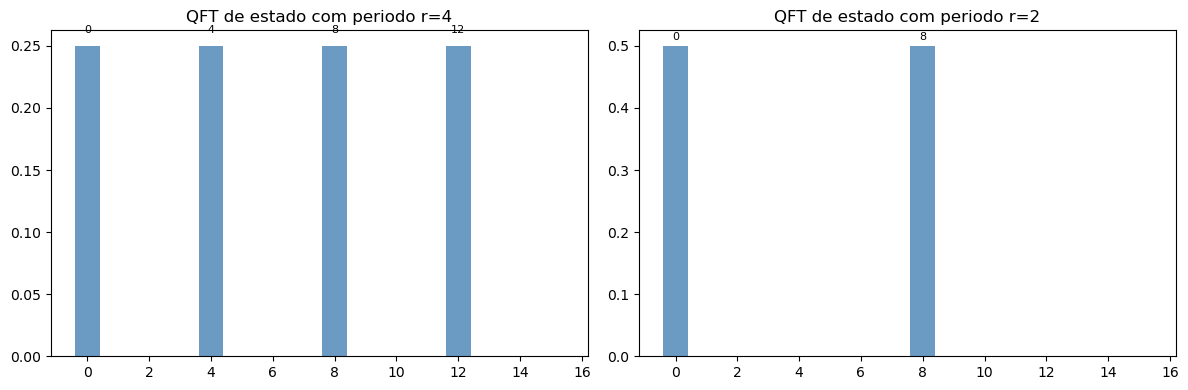

In [7]:
# Demonstrar
n_demo = 4
dev_demo = qml.device('default.qubit', wires=n_demo)

def periodic_state(period, n_qubits):
    """Cria um estado uniforme nos multiplos de periodo."""
    N = 2**n_qubits
    state = np.zeros(N) # cria um vetor com N 
    positions = list(range(0, N, period))
    for pos in positions:
        state[pos] = 1.0 # daquele vetor com N posições a 0, só as posições múltiplas de n tem o valor 1
    return state / np.linalg.norm(state) # normaliza (dividindo por n, pois há n 1's) para garantir que as amplitudes ao quadrado somam 1

@qml.qnode(dev_demo)
def demo_qft_period(period):
    qml.StatePrep(periodic_state(period, n_demo), wires=range(n_demo)) # há a preparação dos qubits. Neste caso há a criação de 16 qubits, mas apenas 4 deles
    # tem amplitude não negativa 
    qft_circuit(wires=list(range(n_demo)))
    return qml.probs(wires=range(n_demo))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for r in [4, 2]:
    probs = demo_qft_period(r)
    ax = axes[0] if r == 4 else axes[1]
    ax.bar(range(2**n_demo), probs, color='steelblue', alpha=0.8)
    ax.set_title(f'QFT de estado com periodo r={r}')
    picos = [i for i, p in enumerate(probs) if p > 0.01]
    for p in picos:
        ax.annotate(f'{p}', (p, probs[p]+0.01), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

Aplicando a QFT a este $|\psi\rangle$, o resultado é:

$$QFT|\psi\rangle = \frac{1}{2}\Big(|0000\rangle + |0100\rangle + |1000\rangle + |1100\rangle\Big)$$

que em posições decimais é: 0, 4, 8, 12, cada um com probabilidade $\frac{1}{4}$.

Antes e depois da QFT, as amplitudes nos múltiplos de 4: {0, 4, 8, 12} é igual aos picos de probabilidade em {0, 4, 8, 12}
Neste caso particular (período = N/4 = 4) acontece que os picos da saída coincidem com os da entrada, mas isso é uma coincidência deste período específico. Para periodo = 2, a entrada seria {0, 2, 4, 6, 8, 10, 12, 14} e a saída seria {0, 8}, pois o espaçamento seria 16/2, evidência de que a QFT comprime a informação do período num número de picos $= r$.



## Parte 2 - Quantum Period Finding para N=15, a=7

Para garantir que a ordem dos bits está correta, usei a convenção:
- Registos de contagem `0..n_count-1` onde `0` é o bit mais significativo.
- O qubit `j` controla a operação multiplicativa $U^{2^{n_{count}-1-j}}$.

In [ ]:
def make_mod_mult_unitary(a, N, n_bits):
    dim = 2 ** n_bits
    U = np.zeros((dim, dim), dtype=complex)
    for x in range(dim):
        y = (a * x) % N if x < N else x
        U[y, x] = 1.0
    return U # Constrói a matriz unitária que na coluna x tem o valor 1 na linha = 7*x mod N.
# U∣x⟩=∣7xmod15⟩
# ∣1⟩→∣7⟩→∣4⟩→∣13⟩→∣1⟩ o estado regressa ao estado incial após 4 vezes, logo o periodo é 4 
N15, a15, n_count15, n_target15 = 15, 7, 4, 4 # a escolha de a é tal que gcd (a,15) = 1
# a escolha de n_target tem que ver com log2​(15) = n_target; este registo armazena valores de 0 a N e em binario sao precisos 4bits para isso
# a escola de n_count tem a ver com este registo ser usado na estimação de fase para determinar o período r.
# 2^(n_count) ≥r^2
dev15 = qml.device('default.qubit', wires=n_count15 + n_target15) 

@qml.qnode(dev15)
def qpf_circuit_N15():
    # Registo alvo em |1>
    qml.BasisState(np.array([0]*n_count15 + [0]*(n_target15-1) + [1]), wires=range(n_count15+n_target15))
    
    for w in range(n_count15):
        qml.Hadamard(wires=w) # os 4 qubits de contagem passam para sobreposição uniforme

    # Multiplicacoes controladas
    for j in range(n_count15):
        power = pow(a15, 2**(n_count15-1-j), N15)
        U_pow = make_mod_mult_unitary(power, N15, n_target15)
        qml.ctrl(qml.QubitUnitary, control=j)(U_pow, wires=list(range(n_count15, n_count15+n_target15)))
        # Para cada qubit j do registo de contagem
        # ∣x⟩⟶∣a^x mod N ⟩
        # seja x=b_(n−1)*​2^(n−1)+b_(n−2​)*2^(n−2)+⋯+b_1*​2^1+b_0*​2_0, onde b são os qubits 1 ou 0 de n_count
        # então a^x=a^(2^(n−1)b_(n-1))​⋅a^(2^(n−2)b_(n-2))​⋯a^((2^0)b_0)​
        # por exemplo, 
        # 7^1 mod 15 = 7   <=> b_0
        # 7^2 mod 15 = 4   <=> b_1
        # 7^4 mod 15 = 1   <=> b_2
        # 7^8 mod 15 = 1   <=> b_3
        # seja x=5
        # 7^5 = 13 mod 15
#Se o qubit j for |1> → aplica a multiplicação por a^{2^{n-1-j}} mod N ao registo de target
#Se o qubit j for |0> → não faz nada


    # QFT inversa ao registo de contagem
    qft_inv(range(n_count15)) # Como o estado do registo de target tem período r=4 (porque 7^4 é equivalente a 1 mod(15), a QFT inversa cria picos de interferência nos múltiplos de N/r = 16/4 = 4, nomeadamente picos em: {0, 4, 8, 12}
    
    return qml.probs(wires=range(n_count15))

probs15 = qpf_circuit_N15()
picos15 = [(i, p) for i, p in enumerate(probs15) if p > 0.05]
print(f'Picos para N=15, a=7: {picos15}')

Picos para N=15, a=7: [(0, 0.24999999999999967), (4, 0.24999999999999967), (8, 0.24999999999999967), (12, 0.24999999999999967)]


Cada outcome, k, corresponde a uma fase = k/16
uma vez encontrado o periodo, r=4, calcula-se a^(r/2) = 49
e então gcd(49−1,15)= 3 e gcd(49+1,15)=5, pelo que 3 x 5 = 15!

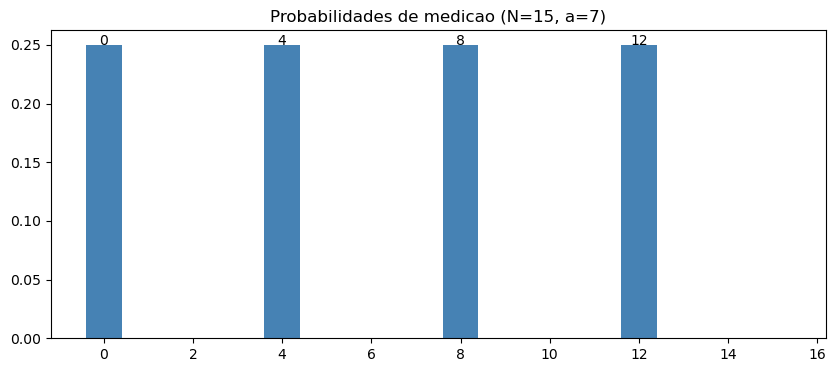

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(16), probs15, color='steelblue')
ax.set_title("Probabilidades de medicao (N=15, a=7)")
for outcome, prob in picos15:
    ax.annotate(f"{outcome}", (outcome, prob), ha='center')
plt.show()

### Extração do Período

Para outcome=4: fase = 4/16 = 1/4. O denominador é r=4.
Para outcome=12: fase = 12/16 = 3/4. O denominador é r=4.

In [10]:
for outcome, prob in picos15:
    if outcome == 0: continue
    phase = outcome / 16
    frac = Fraction(phase).limit_denominator(15)
    r = frac.denominator
    print(f"Outcome {outcome}: fase {phase} ~ {frac} -> r={r}")

Outcome 4: fase 0.25 ~ 1/4 -> r=4
Outcome 8: fase 0.5 ~ 1/2 -> r=2
Outcome 12: fase 0.75 ~ 3/4 -> r=4


Aqui, o outcome k=0 não foi considerado pois corresponde à fase 0/16 = 0. ao converter esta fase em fração irredutível obtem-se 0/1 e 1 não contém nenhuma informação útil sobre o período, ao contrário dos outros outcomes, p.ex. k=4, onde a fase é 4/16 = 1/4 e aqui já temos r = 4, que faz mais sentido.

## Parte 4 — Casos de Falha

### 1. r é ímpar
Se escolhermos **a=11** para N=15?
11^1=11, 11^2=121≡1 mod 15. r=2 (par). Funciona.
E para **a=14**?
14^1=14, 14^2=1 mod 15. r=2 (par). Funciona.

No caso de N=15, todos os `a` coprimos têm `r` par. Mas para outros números (como N=21), escolher um `a` que resulte em `r` ímpar é possível e causaria falha.

## Parte 5 (Tarefa 2) - Fatorizar N=21

Para N=21, a=2, r=6

In [12]:
N21, a21, n_count21, n_target21 = 21, 2, 6, 5
dev21 = qml.device('default.qubit', wires=n_count21 + n_target21)

@qml.qnode(dev21)
def qpf_circuit_N21():
    qml.BasisState(np.array([0]*n_count21 + [0]*(n_target21-1) + [1]), wires=range(n_count21+n_target21))
    for w in range(n_count21): qml.Hadamard(wires=w)
    for j in range(n_count21):
        p = pow(a21, 2**(n_count21-1-j), N21)
        U = make_mod_mult_unitary(p, N21, n_target21)
        qml.ctrl(qml.QubitUnitary, control=j)(U, wires=range(n_count21, n_count21+n_target21))
    qft_inv(range(n_count21))
    return qml.probs(wires=range(n_count21))

print("A calcular picos para N=21...")
probs21 = qpf_circuit_N21()
picos21 = [(i, p) for i, p in enumerate(probs21) if p > 0.05]
print(f"Picos encontrados: {[p[0] for p in picos21]}")

A calcular picos para N=21...
Picos encontrados: [0, 11, 21, 32, 43, 53]


No caso de k = {21,32,43},  a fração aproximada é 1/3, 1/2 e 2/3, respetivamente. Ora, os denominadores não são iguais a 6, mas são múltiplos de 6. Isto acontece quando o numerador e denominador têm fatores comuns. Por este motivo de poder haver r candidatos < r, é indispensável validar o período candidato antes de o usar:
a^(r_candidato) = 1 mod N e se for válida esta condição, r é válido.